# Key Finding from EDA
- No null values or duplicate data row found.
- High class imbalance for training (90%+ absent data over presence).
- Limited train data for few species with as low as 3 data rows.
- Disturb feature out of bounds max should be 3 but few rows with value 4 found.
- High correlation between long-easting & lat-northing is observed.
- Low variance influence factor between other features.

# Data Preprocessing Steps Implemented
- Converting species to categorical type (everytime after importing).
- Removal of plot column as its just for grouping rows.
- Exclude longitude & latitude value as easting and northing are provided.
- Limiting disturb at value 3 instead of 4.
- Converted data to wide format for SSDM.
- Stratified train & test split to ensure each species used for training and evaluating a model with stratified presence absence ratio.


# Importing Required Libraries

In [1]:
# 1. Required modules
import os
import numpy as np
import pandas as pd
import kagglehub

# 2. Visualisation tools
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Data analytics tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

import joblib

# Importing Dataset

In [2]:
path = kagglehub.competition_download('predicting-small-reptile-species-distributions-in-nsw')

print('Path to competition files:', path)

Path to competition files: /Users/dhruvsalot/.cache/kagglehub/competitions/predicting-small-reptile-species-distributions-in-nsw


In [3]:
# 1. Load the data
df = pd.read_csv(f'{path}/train.csv', index_col='id')
infer_df = pd.read_csv(f'{path}/test.csv', index_col='id')

In [4]:
# 2. Preview of train/test data
df.head()

,long,lat,disturb,rainann,soildepth,soilfert,tempann,topo,easting,northing,plot,Species,pres.abs
id,,,,,,,,,,,,,
1,153.4889,-28.1669,3,1588,1139,2,200,0,-41493.928042,6.871991e+06,1,Cacophis kreftii,0
2,153.4889,-28.1669,3,1588,1139,2,200,0,-41493.928042,6.871991e+06,1,Calyptotis scutirostrum,0
3,153.4889,-28.1669,3,1588,1139,2,200,0,-41493.928042,6.871991e+06,1,Coeranoscincus reticulatus,0
4,153.4889,-28.1669,3,1588,1139,2,200,0,-41493.928042,6.871991e+06,1,Egernia mcpheei,0
5,153.4889,-28.1669,3,1588,1139,2,200,0,-41493.928042,6.871991e+06,1,Eulamprus murrayi,0


In [5]:
# 3. Preview of infer data
infer_df.head()

,long,lat,disturb,rainann,soildepth,soilfert,tempann,topo,easting,northing,plot,Species
id,,,,,,,,,,,,
5129,153.4828,-28.1651,3,1592,1149,2,200,-3,-42103.432678,6.872164e+06,642,Cacophis kreftii
5130,153.4828,-28.1651,3,1592,1149,2,200,-3,-42103.432678,6.872164e+06,642,Calyptotis scutirostrum
5131,153.4828,-28.1651,3,1592,1149,2,200,-3,-42103.432678,6.872164e+06,642,Coeranoscincus reticulatus
5132,153.4828,-28.1651,3,1592,1149,2,200,-3,-42103.432678,6.872164e+06,642,Egernia mcpheei
5133,153.4828,-28.1651,3,1592,1149,2,200,-3,-42103.432678,6.872164e+06,642,Eulamprus murrayi


In [6]:
# 4. Info about the train/test data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5128 entries, 1 to 5128
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   long       5128 non-null   float64
 1   lat        5128 non-null   float64
 2   disturb    5128 non-null   int64  
 3   rainann    5128 non-null   int64  
 4   soildepth  5128 non-null   int64  
 5   soilfert   5128 non-null   int64  
 6   tempann    5128 non-null   int64  
 7   topo       5128 non-null   int64  
 8   easting    5128 non-null   float64
 9   northing   5128 non-null   float64
 10  plot       5128 non-null   int64  
 11  Species    5128 non-null   str    
 12  pres.abs   5128 non-null   int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 520.9 KB


In [7]:
# 5. Info about the infer data
infer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2936 entries, 5129 to 8064
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   long       2936 non-null   float64
 1   lat        2936 non-null   float64
 2   disturb    2936 non-null   int64  
 3   rainann    2936 non-null   int64  
 4   soildepth  2936 non-null   int64  
 5   soilfert   2936 non-null   int64  
 6   tempann    2936 non-null   int64  
 7   topo       2936 non-null   int64  
 8   easting    2936 non-null   float64
 9   northing   2936 non-null   float64
 10  plot       2936 non-null   int64  
 11  Species    2936 non-null   str    
dtypes: float64(4), int64(7), str(1)
memory usage: 275.4 KB


<div class='alert alert-block alert-info'>
<b>Note:</b> There are no null values found in both train and inference dataset since total entries = number of non null values for each column. Tghe Species column is in str format which need to be converted to categorical type for further analysis.</div>

In [8]:
# 6. Converting to categorical data

df['species'] = df['Species'].astype('category')
infer_df['species'] = infer_df['Species'].astype('category')

# df['disturb'] = df['disturb'].astype('category')
# infer_df['disturb'] = infer_df['disturb'].astype('category')

# df['soilfert'] = df['soilfert'].astype('category')
# infer_df['soilfert'] = infer_df['soilfert'].astype('category')

df = df.drop(columns=['Species'])
infer_df = infer_df.drop(columns=['Species'])

In [9]:
# 7. Descriptive statistics of the train/test data
df.describe()

,long,lat,disturb,rainann,soildepth,soilfert,tempann,topo,easting,northing,plot,pres.abs
count,5128.000000,5128.000000,5128.000000,5128.000000,5128.000000,5128.000000,5128.000000,5128.000000,5128.000000,5.128000e+03,5128.000000,5128.000000
mean,152.593551,-29.715582,2.113885,1496.808112,1085.171607,2.399376,156.770671,3.776911,-119743.338611,6.695319e+06,321.000000,0.063378
std,0.550075,1.191761,0.873230,397.582963,97.671355,1.163625,25.087988,16.148381,48400.849863,1.345845e+05,185.058581,0.243665
min,151.163200,-32.625200,1.000000,692.000000,800.000000,1.000000,89.000000,-42.000000,-245153.452723,6.367199e+06,1.000000,0.000000
25%,152.247700,-30.548800,1.000000,1212.000000,1029.000000,2.000000,137.000000,-5.000000,-152439.192169,6.601391e+06,161.000000,0.000000
50%,152.552700,-29.545500,2.000000,1440.000000,1080.000000,2.000000,160.000000,1.000000,-122504.375188,6.712676e+06,321.000000,0.000000
75%,153.072100,-28.579100,3.000000,1668.000000,1129.000000,2.000000,178.000000,12.000000,-77534.095329,6.825382e+06,481.000000,0.000000
max,153.612300,-28.166900,4.000000,3150.000000,1370.000000,5.000000,200.000000,142.000000,-26577.824177,6.871991e+06,641.000000,1.000000


In [10]:
# 8. Descriptive statistics of the infer data
infer_df.describe()

,long,lat,disturb,rainann,soildepth,soilfert,tempann,topo,easting,northing,plot
count,2936.000000,2936.000000,2936.000000,2936.00000,2936.000000,2936.000000,2936.000000,2936.000000,2936.000000,2.936000e+03,2936.000000
mean,152.575702,-29.814589,2.239782,1362.13079,1088.569482,2.171662,159.226158,1.414169,-120985.184982,6.684221e+06,825.000000
std,0.560275,1.038537,0.878126,353.27933,94.459733,1.049618,24.843783,14.149462,50340.679698,1.174063e+05,105.961428
min,151.087400,-32.201600,1.000000,712.00000,829.000000,1.000000,103.000000,-45.000000,-253975.462234,6.411392e+06,642.000000
25%,152.170400,-30.182300,1.000000,1184.00000,1029.000000,2.000000,137.000000,-6.000000,-155253.030774,6.645293e+06,733.000000
50%,152.659800,-29.777700,2.000000,1314.00000,1080.000000,2.000000,161.000000,0.000000,-116701.035778,6.691186e+06,825.000000
75%,152.958500,-29.034300,3.000000,1464.00000,1120.000000,2.000000,184.000000,9.000000,-84985.288308,6.773196e+06,917.000000
max,153.548900,-28.165100,4.000000,3552.00000,1340.000000,5.000000,200.000000,60.000000,-34765.473918,6.872164e+06,1008.000000


# Data Analytics & Preprocessing

## Checking for Duplicated Rows

In [11]:
# 1. Check for duplicated rows
print(f'Number of duplicated rows = {df.duplicated().sum()}')

Number of duplicated rows = 0


## Analytics by Species

In [12]:
# 1. Aggregation of train/test data by species
train_species_summary = (
    df.groupby("species")["pres.abs"]
    .agg(
        total_records="count",
        presence_count="sum",
        presence_rate="mean"
    )
    .sort_values("presence_count")
)

train_species_summary

,total_records,presence_count,presence_rate
species,,,
Eulamprus murrayi,641,3,0.004680
Saltuarius swaini,641,8,0.012480
Egernia mcpheei,641,12,0.018721
Pseudechis porphyricaus,641,14,0.021841
Cacophis kreftii,641,20,0.031201
Calyptotis scutirostrum,641,50,0.078003
Coeranoscincus reticulatus,641,104,0.162246
Ophioscincus truncatus,641,114,0.177847


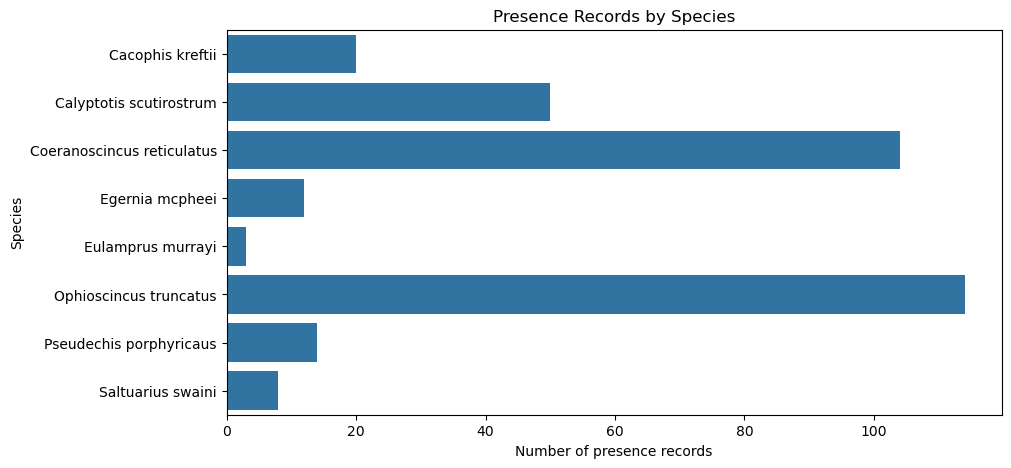

In [13]:
# 2. Barchart visualizing presence of species

plt.figure(figsize=(10, 5))
sns.barplot(
    data=train_species_summary.reset_index(),
    x="presence_count",
    y="species"
)
plt.xlabel("Number of presence records")
plt.ylabel("Species")
plt.title("Presence Records by Species")
plt.show()

<div class='alert alert-block alert-info'>
<b>Note:</b> The dataset is highly imbalanced across species. Some species, such as Eulamprus murrayi and Saltuarius swaini, have very few presence records, while Ophioscincus truncatus and Coeranoscincus reticulatus are much more common. This supports the project motivation for comparing separate single-species models with a joint single-species model, since rare species may benefit from information shared across species.</div>

## Removal of identity features

In [14]:
# 1. Removing plot from dataset
df = df.drop(columns=['plot'])
infer_df = infer_df.drop(columns=['plot'])

## Data sanity checks

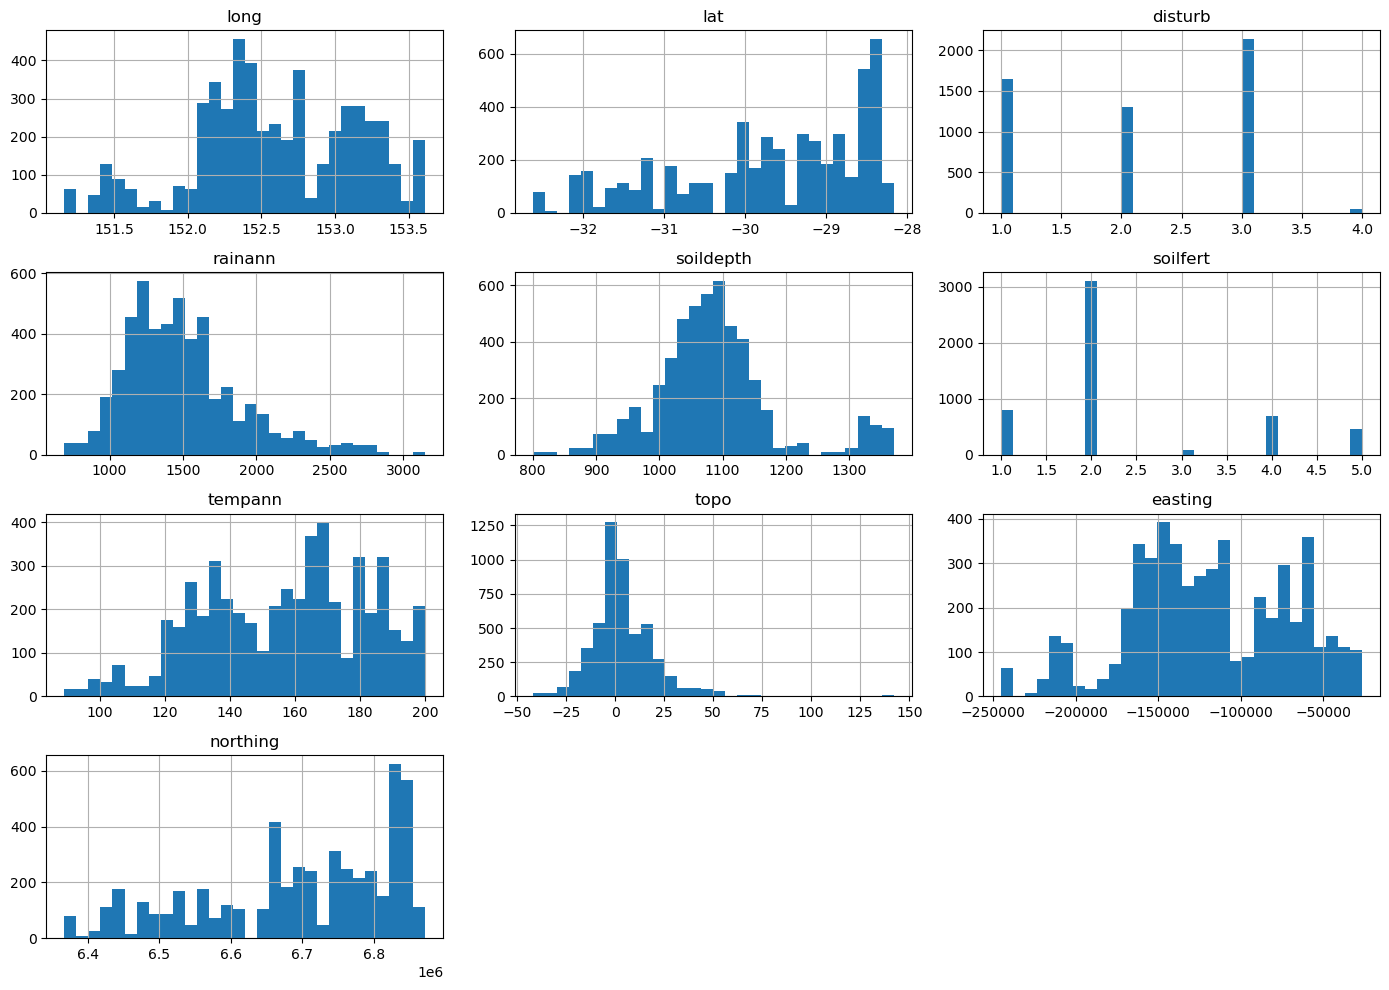

In [15]:
# 1. Range and distribution of all features in train data
predictor_cols = [
    "long", "lat", "disturb", "rainann", "soildepth",
    "soilfert", "tempann", "topo", "easting", "northing"
]

df[predictor_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

<div class='alert alert-block alert-info'>
<b>Note:</b> We see that the max observed value of disturb feature is 4, however according to the data description its a factor describing the extent of disturbance. 1=light, 2-moderate, 3=heavy only. We can convert all values of 4 to 3 (heavy) too keep our data uniform. Another thing to not is an outlier in topo feature with only single value above 125. We infer from this to use Robust Scaler instead of Standard Scaler.</div>

In [16]:
# 2. Look up disturb value of 4.
df[df['disturb'] == 4].head()

,long,lat,disturb,rainann,soildepth,soilfert,tempann,topo,easting,northing,pres.abs,species
id,,,,,,,,,,,,
1145,153.5356,-28.5422,4,1810,1360,1,198,0,-35003.902598,6.830519e+06,0,Cacophis kreftii
1146,153.5356,-28.5422,4,1810,1360,1,198,0,-35003.902598,6.830519e+06,0,Calyptotis scutirostrum
1147,153.5356,-28.5422,4,1810,1360,1,198,0,-35003.902598,6.830519e+06,0,Coeranoscincus reticulatus
1148,153.5356,-28.5422,4,1810,1360,1,198,0,-35003.902598,6.830519e+06,0,Egernia mcpheei
1149,153.5356,-28.5422,4,1810,1360,1,198,0,-35003.902598,6.830519e+06,0,Eulamprus murrayi


In [17]:
# 3. Replace all disturb value of 4 to 3.
df['disturb'] = df['disturb'].replace(4, 3)
infer_df['disturb'] = infer_df['disturb'].replace(4, 3)

## Checking for collinear spatial features (lat/long vs northing/easting)

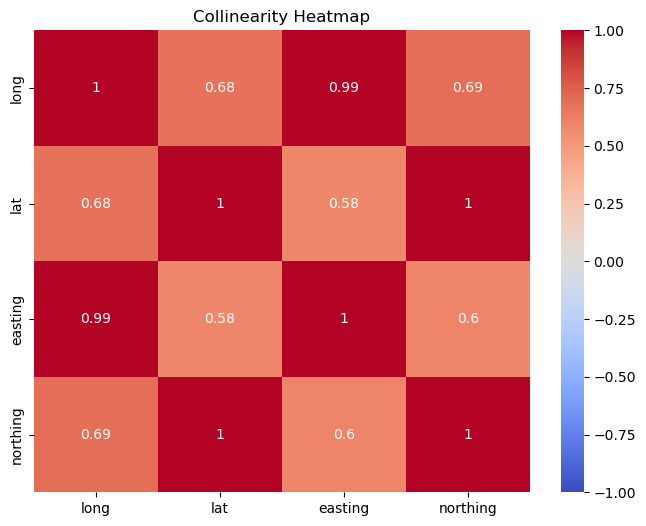

In [18]:
# 1. Spatial features
spatial_features = ['long', 'lat', 'easting', 'northing']
subset_df = df[spatial_features]

# 2. Compute correlation matrix and print
corr_matrix = subset_df.corr()

# 3. Visualize using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Collinearity Heatmap')
plt.show()

<div class='alert alert-block alert-info'>
<b>Note:</b> High correlation between long-easting & lat-northing is observed as expected. We will only keep easting-northing pairs as it provides Cartesian, equal-area representation for spatial trend modelling.</div>

In [19]:
# 5. Removing long & lat from dataset
df = df.drop(columns=['long', 'lat'])
infer_df = infer_df.drop(columns=['long', 'lat'])

In [20]:
# 4. Calculate variance inflation factor (VIF)
# VIF > 5 indicates severe multicollinearity

spatial_features = ['easting', 'northing']
subset_df = df[spatial_features]
X = add_constant(subset_df)

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print('\nVariance Inflation Factor (VIF):')
vif_data = vif_data[vif_data['Feature'] != 'const']
print(vif_data)


Variance Inflation Factor (VIF):
    Feature       VIF
1   easting  1.555503
2  northing  1.555503


<div class='alert alert-block alert-info'>
<b>Note:</b> The calculated VIF score of approximately 1.56 (<5) for both easting and northing indicates very low correlation between these spatial coordinates, meaning they can safely remain in your regression model without any multicollinearity issues.</div>


## Checking for collinearity between other features

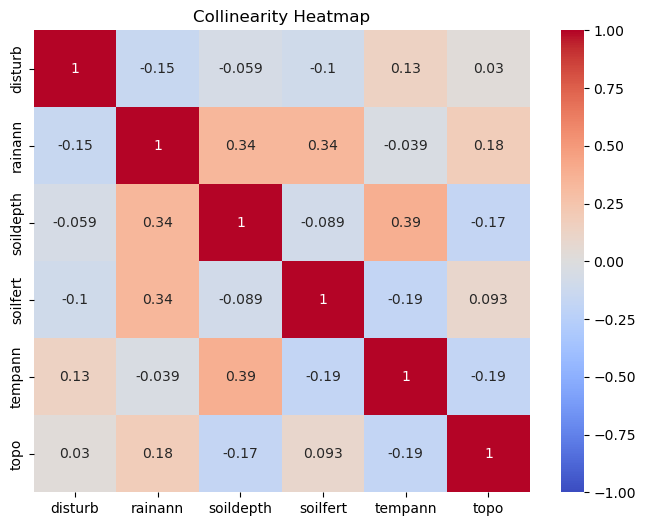

In [21]:
# 1. Features
features = ['disturb', 'rainann', 'soildepth', 'soilfert', 'tempann', 'topo']
subset_df = df[features]

# 2. Compute correlation matrix and print
corr_matrix = subset_df.corr()

# 3. Visualize using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Collinearity Heatmap')
plt.show()

In [22]:
# 4. Calculate variance inflation factor (VIF)
# VIF > 5 indicates severe multicollinearity
X = add_constant(subset_df)

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print('\nVariance Inflation Factor (VIF):')
vif_data = vif_data[vif_data['Feature'] != 'const']
print(vif_data)


Variance Inflation Factor (VIF):
     Feature       VIF
1    disturb  1.053698
2    rainann  1.471833
3  soildepth  1.494269
4   soilfert  1.213114
5    tempann  1.274355
6       topo  1.120635


<div class='alert alert-block alert-info'>
<b>Note:</b> The calculated VIF scores for all six features range between 1.05 and 1.49 (<5), indicating negligible correlation among your environmental predictors and confirming that the model is entirely free from problematic multicollinearity.</div>

# 80/20 Train-Test Split & Saving Dataset

<div class='alert alert-block alert-info'>
<b>Note:</b> With severe class imbalance (some species have as few as 3 presences), a random split risks putting all presences of a rare species into one portion. Hence we use <b>stratified train test splitting</b>. A stratified train-test split is a data-partitioning method that preserves the exact percentage or proportion of each class or category in both the resulting training and testing subsets as found in the original dataset.</div>

In [23]:
# 1. Splitting function
def split(df, y, species=None, test_size=0.2,):

    # Split the data, stratifying by the target variable or both target and group
    stratify = y

    if species:
        stratify = df['species'].astype(str) + ',' + df['pres.abs'].astype(str)
        stratify = stratify.astype('category')

    X_train, X_test, y_train, y_test = train_test_split(
        df, y, test_size=test_size, stratify=stratify, random_state=42
    )

    X_train = X_train.drop(columns=['pres.abs'])
    X_test  = X_test.drop(columns=['pres.abs'])

    return(X_train, X_test, y_train, y_test)

## Data splitting for JSDM

In [24]:
# 1. Joint-species data splitting (long format)
y = df['pres.abs']

X_train, X_test, y_train, y_test = split(df, y=y, species='species')

In [25]:
# 2. Generating JSDM train data
jsdm_train = X_train
jsdm_train['pres.abs'] = y_train
jsdm_train = jsdm_train.reset_index(drop=True)

In [26]:
# 3. Generating JSDM test data
jsdm_test = X_test
jsdm_test['pres.abs'] = y_test
jsdm_test = jsdm_test.reset_index(drop=True)

In [27]:
# 4. Train data preview
jsdm_train.head()

,disturb,rainann,soildepth,soilfert,tempann,topo,easting,northing,species,pres.abs
0,3,1566,1110,2,193,-3,-47276.750228,6.763369e+06,Calyptotis scutirostrum,0
1,1,1454,1320,1,194,1,-45846.344132,6.770875e+06,Egernia mcpheei,0
2,2,1390,1100,5,166,-15,-111724.493680,6.796891e+06,Eulamprus murrayi,0
3,1,1828,1049,2,122,19,-139653.179397,6.591583e+06,Coeranoscincus reticulatus,0
4,3,1396,1100,2,179,-15,-99523.104620,6.530559e+06,Ophioscincus truncatus,0


In [28]:
# 5. Test data preview
jsdm_train.head()

,disturb,rainann,soildepth,soilfert,tempann,topo,easting,northing,species,pres.abs
0,3,1566,1110,2,193,-3,-47276.750228,6.763369e+06,Calyptotis scutirostrum,0
1,1,1454,1320,1,194,1,-45846.344132,6.770875e+06,Egernia mcpheei,0
2,2,1390,1100,5,166,-15,-111724.493680,6.796891e+06,Eulamprus murrayi,0
3,1,1828,1049,2,122,19,-139653.179397,6.591583e+06,Coeranoscincus reticulatus,0
4,3,1396,1100,2,179,-15,-99523.104620,6.530559e+06,Ophioscincus truncatus,0


## Data Standardization

In [29]:
# 1. Defining preprocessor
cat_cols = ['species']
num_cols = ['rainann', 'soildepth', 'tempann', 'topo', 'easting', 'northing']
species = all_species = list(df['species'].unique())

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(categories=[all_species]), cat_cols)
    ],
    remainder='passthrough'
)

# 2. Applying transform
transformed_data = preprocessor.fit_transform(jsdm_train)

# 3. Preview of transformed data
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['num__rainann' 'num__soildepth' 'num__tempann' 'num__topo' 'num__easting'
 'num__northing' 'cat__species' 'remainder__disturb' 'remainder__soilfert'
 'remainder__pres.abs']


In [30]:
# 4. Feature name transform
feature_names = list(map(lambda x: x.split('__')[1], feature_names))
feature_names

['rainann',
 'soildepth',
 'tempann',
 'topo',
 'easting',
 'northing',
 'species',
 'disturb',
 'soilfert',
 'pres.abs']

In [31]:
# 5. Making new data frame from scaled data
jsdm_train_processed = pd.DataFrame(transformed_data, columns=feature_names)

# 6. Preview of train data
jsdm_train_processed.head()

,rainann,soildepth,tempann,topo,easting,northing,species,disturb,soilfert,pres.abs
0,0.275109,0.329670,0.804878,-0.235294,1.014579,0.237325,1.0,3.0,2.0,0.0
1,0.030568,2.637363,0.829268,0.000000,1.033768,0.271735,3.0,1.0,1.0,0.0
2,-0.109170,0.219780,0.146341,-0.941176,0.150008,0.391013,4.0,2.0,5.0,0.0
3,0.847162,-0.340659,-0.926829,1.058824,-0.224657,-0.550282,2.0,1.0,2.0,0.0
4,-0.096070,0.219780,0.463415,-0.941176,0.313691,-0.830064,5.0,3.0,2.0,0.0


## Train data saving

In [32]:
# 1. Saving train data
os.makedirs('./data/jsdm', exist_ok=True)
jsdm_train_processed.to_csv('./data/jsdm/train.csv', index=False)

## Standardizing test dataset

In [33]:
# 1. Applying transform
transformed_data = preprocessor.transform(jsdm_test)

In [34]:
# 2. Making new data frame from scaled data
jsdm_test_processed = pd.DataFrame(transformed_data, columns=feature_names)

# 3. Preview of train data
jsdm_test_processed.head()

,rainann,soildepth,tempann,topo,easting,northing,species,disturb,soilfert,pres.abs
0,0.327511,0.439560,-0.829268,2.588235,-0.211567,-0.513134,5.0,1.0,2.0,0.0
1,0.471616,0.000000,-0.097561,0.941176,-1.129674,-1.341965,7.0,2.0,3.0,0.0
2,0.340611,2.747253,0.682927,-0.058824,0.975309,-0.002994,6.0,2.0,1.0,0.0
3,-0.458515,-0.560440,-0.560976,0.823529,-0.520818,-0.013841,0.0,3.0,1.0,0.0
4,0.257642,0.329670,0.000000,-0.470588,-0.198514,0.669131,3.0,2.0,2.0,0.0


## Test data saving

In [35]:
# 1. Saving test data
os.makedirs('./data/jsdm', exist_ok=True)
jsdm_test_processed.to_csv('./data/jsdm/test.csv', index=False)

## Saving preprocessor

In [36]:
# Dumping preprocessor as pkl
os.makedirs('./preprocessor', exist_ok=True)
file = joblib.dump(preprocessor, './preprocessor/jsdm.pkl')

## Summary by species of train & test data

In [37]:
# 1. Summarizing train data by species
summary = (
    jsdm_train.groupby("species")["pres.abs"]
    .agg(
        total_records="count",
        presence_count="sum",
        presence_rate="mean"
    )
    .sort_values("presence_count")
)

print('Train data summary:')
summary

Train data summary:


,total_records,presence_count,presence_rate
species,,,
Eulamprus murrayi,512,2,0.003906
Saltuarius swaini,512,6,0.011719
Egernia mcpheei,513,10,0.019493
Pseudechis porphyricaus,513,11,0.021442
Cacophis kreftii,513,16,0.031189
Calyptotis scutirostrum,513,40,0.077973
Coeranoscincus reticulatus,513,83,0.161793
Ophioscincus truncatus,513,91,0.177388


In [38]:
# 2. Summarizing test data by species
summary = (
    jsdm_test.groupby("species")["pres.abs"]
    .agg(
        total_records="count",
        presence_count="sum",
        presence_rate="mean"
    )
    .sort_values("presence_count")
)

print('Test data summary:')
summary

Test data summary:


,total_records,presence_count,presence_rate
species,,,
Eulamprus murrayi,129,1,0.007752
Egernia mcpheei,128,2,0.015625
Saltuarius swaini,129,2,0.015504
Pseudechis porphyricaus,128,3,0.023438
Cacophis kreftii,128,4,0.031250
Calyptotis scutirostrum,128,10,0.078125
Coeranoscincus reticulatus,128,21,0.164062
Ophioscincus truncatus,128,23,0.179688


## Data splitting for SSDM

In [39]:
# 1. Single-species data splitting (wide format)

all_species = list(df['species'].unique())

total_records_train = []
total_records_test  = []

presence_count_train = []
presence_count_test  = []

presence_rate_train = []
presence_rate_test  = []


num_cols = ['rainann', 'soildepth', 'tempann', 'topo', 'easting', 'northing']

for species in all_species:
    # 1. Splitting by species
    species_train_df = jsdm_train[jsdm_train['species'] == species]
    species_test_df = jsdm_test[jsdm_test['species'] == species]

    species_train_df.drop(columns=['species'], inplace=True)
    species_test_df.drop(columns=['species'], inplace=True)

    # 2. Logs
    total_records_train.append(len(species_train_df))
    total_records_test.append(len(species_test_df))

    presence_count_train.append(species_train_df['pres.abs'].sum())
    presence_count_test.append(species_test_df['pres.abs'].sum())

    presence_rate_train.append(presence_count_train[-1]/total_records_train[-1])
    presence_rate_test.append(presence_count_test[-1]/total_records_test[-1])

    # 3. Standardizing
    preprocessor = ColumnTransformer(
        transformers=[
                ('num', RobustScaler(), num_cols),
            ],
            remainder='passthrough'
    )
    
    transformed_data = preprocessor.fit_transform(species_train_df)
    transformed_test_data = preprocessor.transform(species_test_df)

    # 4. Generating new standardized df
    feature_names = preprocessor.get_feature_names_out()
    feature_names = list(map(lambda x: x.split('__')[1], feature_names))
    
    # 5. Making new data frame from scaled data
    species_train_df = pd.DataFrame(transformed_data, columns=feature_names)
    species_test_df = pd.DataFrame(transformed_test_data, columns=feature_names)

    # 6. Saving preprocessor
    os.makedirs(f'./preprocessor/ssdm/{species}', exist_ok=True)
    file = joblib.dump(preprocessor, f'./preprocessor/ssdm/{species}/preprocessor.pkl')
    
    # 7. Saving data
    os.makedirs(f'./data/ssdm/{species}', exist_ok=True)
    species_train_df.to_csv(f'./data/ssdm/{species}/train.csv', index=False)
    species_test_df.to_csv(f'./data/ssdm/{species}/test.csv', index=False)

## Summarizing single species data

In [40]:
# 1. Summarizing train data by species

summary_train = pd.DataFrame({
    'species': all_species,
    'total_records': total_records_train,
    'presence_count': presence_count_train,
    'presence_rate': presence_rate_train
})

print('Train data summary:')
summary_train.sort_values(by='presence_count')

Train data summary:


,species,total_records,presence_count,presence_rate
4,Eulamprus murrayi,512,2,0.003906
7,Saltuarius swaini,512,6,0.011719
3,Egernia mcpheei,513,10,0.019493
6,Pseudechis porphyricaus,513,11,0.021442
0,Cacophis kreftii,513,16,0.031189
1,Calyptotis scutirostrum,513,40,0.077973
2,Coeranoscincus reticulatus,513,83,0.161793
5,Ophioscincus truncatus,513,91,0.177388


In [41]:
# 2. Summarizing test data by species

summary_test = pd.DataFrame({
    'species': all_species,
    'total_records': total_records_test,
    'presence_count': presence_count_test,
    'presence_rate': presence_rate_test
})

print('Test data summary:')
summary_test.sort_values(by='presence_count')

Test data summary:


,species,total_records,presence_count,presence_rate
4,Eulamprus murrayi,129,1,0.007752
3,Egernia mcpheei,128,2,0.015625
7,Saltuarius swaini,129,2,0.015504
6,Pseudechis porphyricaus,128,3,0.023438
0,Cacophis kreftii,128,4,0.031250
1,Calyptotis scutirostrum,128,10,0.078125
2,Coeranoscincus reticulatus,128,21,0.164062
5,Ophioscincus truncatus,128,23,0.179688


## Saving inference data

In [42]:
#  1. Saving Inference Data
infer_df.to_csv('./data/infer.csv')